In [2]:
import pandas as pd

In [3]:
columns = ["age","sex","cp","trestbps","chol","fbs","restecg","thalach","exang","oldpeak","slope","ca","thal","num",]

df = pd.read_csv("../data/processed_data/processed.cleveland.data", names=columns, na_values="?")

In [4]:
droped_df = df.dropna()
y = droped_df["num"]
droped_df.drop(columns=['num'],inplace=True)
droped_df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57.0,0.0,4.0,140.0,241.0,0.0,0.0,123.0,1.0,0.2,2.0,0.0,7.0
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0


In [5]:
y

0      0
1      2
2      1
3      0
4      0
      ..
297    1
298    1
299    2
300    3
301    1
Name: num, Length: 297, dtype: int64

In [6]:
droped_df['cp'].unique()

array([1., 4., 3., 2.])

In [7]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [8]:
ohe = OneHotEncoder(handle_unknown="ignore",sparse_output=False).set_output(transform="pandas")

In [9]:
ohecp = ohe.fit_transform(droped_df[['cp']])

In [10]:
ohecp

,cp_1.0,cp_2.0,cp_3.0,cp_4.0
0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,1.0
3,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0
...,...,...,...,...
297,0.0,0.0,0.0,1.0
298,1.0,0.0,0.0,0.0
299,0.0,0.0,0.0,1.0
300,0.0,0.0,0.0,1.0


In [11]:
ohecp.columns = ["cp_typical_angina","cp_atypical_angina","cp_non-anginal_pain","cp_asymptomatic"]

In [12]:
ohecp.columns

Index(['cp_typical_angina', 'cp_atypical_angina', 'cp_non-anginal_pain',
       'cp_asymptomatic'],
      dtype='str')

In [13]:
ohecp

,cp_typical_angina,cp_atypical_angina,cp_non-anginal_pain,cp_asymptomatic
0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,1.0
3,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0
...,...,...,...,...
297,0.0,0.0,0.0,1.0
298,1.0,0.0,0.0,0.0
299,0.0,0.0,0.0,1.0
300,0.0,0.0,0.0,1.0


In [14]:
cp_df = pd.concat([droped_df,ohecp],axis=1).drop(columns=["cp"])

In [15]:
cp_df

,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,cp_typical_angina,cp_atypical_angina,cp_non-anginal_pain,cp_asymptomatic
0,63.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,1.0,0.0,0.0,0.0
1,67.0,1.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,0.0,0.0,0.0,1.0
2,67.0,1.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,0.0,0.0,0.0,1.0
3,37.0,1.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0.0,0.0,1.0,0.0
4,41.0,0.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57.0,0.0,140.0,241.0,0.0,0.0,123.0,1.0,0.2,2.0,0.0,7.0,0.0,0.0,0.0,1.0
298,45.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1.0,0.0,0.0,0.0
299,68.0,1.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,0.0,0.0,0.0,1.0
300,57.0,1.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,0.0,0.0,0.0,1.0


In [16]:
oherestecg = ohe.fit_transform(cp_df[['restecg']])

In [17]:
oherestecg

,restecg_0.0,restecg_1.0,restecg_2.0
0,0.0,0.0,1.0
1,0.0,0.0,1.0
2,0.0,0.0,1.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0
...,...,...,...
297,1.0,0.0,0.0
298,1.0,0.0,0.0
299,1.0,0.0,0.0
300,1.0,0.0,0.0


In [18]:
oherestecg.columns = ["restecg_normal","restecg_ST-T_wave_abnormality","restecg_left_ventricular_hypertrophy"]

In [19]:
oherestecg

,restecg_normal,restecg_ST-T_wave_abnormality,restecg_left_ventricular_hypertrophy
0,0.0,0.0,1.0
1,0.0,0.0,1.0
2,0.0,0.0,1.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0
...,...,...,...
297,1.0,0.0,0.0
298,1.0,0.0,0.0
299,1.0,0.0,0.0
300,1.0,0.0,0.0


In [20]:
cp_df

,age,sex,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,cp_typical_angina,cp_atypical_angina,cp_non-anginal_pain,cp_asymptomatic
0,63.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,1.0,0.0,0.0,0.0
1,67.0,1.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,0.0,0.0,0.0,1.0
2,67.0,1.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,0.0,0.0,0.0,1.0
3,37.0,1.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0.0,0.0,1.0,0.0
4,41.0,0.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57.0,0.0,140.0,241.0,0.0,0.0,123.0,1.0,0.2,2.0,0.0,7.0,0.0,0.0,0.0,1.0
298,45.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1.0,0.0,0.0,0.0
299,68.0,1.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,0.0,0.0,0.0,1.0
300,57.0,1.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,0.0,0.0,0.0,1.0


In [21]:
restecg_df = pd.concat([cp_df,oherestecg],axis=1).drop(columns=["restecg"])

In [22]:
restecg_df

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,thal,cp_typical_angina,cp_atypical_angina,cp_non-anginal_pain,cp_asymptomatic,restecg_normal,restecg_ST-T_wave_abnormality,restecg_left_ventricular_hypertrophy
0,63.0,1.0,145.0,233.0,1.0,150.0,0.0,2.3,3.0,0.0,6.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,67.0,1.0,160.0,286.0,0.0,108.0,1.0,1.5,2.0,3.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,67.0,1.0,120.0,229.0,0.0,129.0,1.0,2.6,2.0,2.0,7.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,37.0,1.0,130.0,250.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,41.0,0.0,130.0,204.0,0.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57.0,0.0,140.0,241.0,0.0,123.0,1.0,0.2,2.0,0.0,7.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
298,45.0,1.0,110.0,264.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
299,68.0,1.0,144.0,193.0,1.0,141.0,0.0,3.4,2.0,2.0,7.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
300,57.0,1.0,130.0,131.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [23]:
oheslope = ohe.fit_transform(restecg_df[['slope']])
oheslope

,slope_1.0,slope_2.0,slope_3.0
0,0.0,0.0,1.0
1,0.0,1.0,0.0
2,0.0,1.0,0.0
3,0.0,0.0,1.0
4,1.0,0.0,0.0
...,...,...,...
297,0.0,1.0,0.0
298,0.0,1.0,0.0
299,0.0,1.0,0.0
300,0.0,1.0,0.0


In [24]:
oheslope.columns = ["slope_upsloping","slope_flat","slope_downsloping"]
oheslope

,slope_upsloping,slope_flat,slope_downsloping
0,0.0,0.0,1.0
1,0.0,1.0,0.0
2,0.0,1.0,0.0
3,0.0,0.0,1.0
4,1.0,0.0,0.0
...,...,...,...
297,0.0,1.0,0.0
298,0.0,1.0,0.0
299,0.0,1.0,0.0
300,0.0,1.0,0.0


In [25]:
slope_df = pd.concat([restecg_df,oheslope],axis=1).drop(columns=["slope"])
slope_df


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,thal,cp_typical_angina,cp_atypical_angina,cp_non-anginal_pain,cp_asymptomatic,restecg_normal,restecg_ST-T_wave_abnormality,restecg_left_ventricular_hypertrophy,slope_upsloping,slope_flat,slope_downsloping
0,63.0,1.0,145.0,233.0,1.0,150.0,0.0,2.3,0.0,6.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,67.0,1.0,160.0,286.0,0.0,108.0,1.0,1.5,3.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
2,67.0,1.0,120.0,229.0,0.0,129.0,1.0,2.6,2.0,7.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,37.0,1.0,130.0,250.0,0.0,187.0,0.0,3.5,0.0,3.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,41.0,0.0,130.0,204.0,0.0,172.0,0.0,1.4,0.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57.0,0.0,140.0,241.0,0.0,123.0,1.0,0.2,0.0,7.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
298,45.0,1.0,110.0,264.0,0.0,132.0,0.0,1.2,0.0,7.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
299,68.0,1.0,144.0,193.0,1.0,141.0,0.0,3.4,2.0,7.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
300,57.0,1.0,130.0,131.0,0.0,115.0,1.0,1.2,1.0,7.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0


In [26]:
oheca = ohe.fit_transform(slope_df[['ca']])
ca_df = pd.concat([slope_df, oheca], axis=1).drop(columns=["ca"])
ca_df

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,thal,cp_typical_angina,...,restecg_normal,restecg_ST-T_wave_abnormality,restecg_left_ventricular_hypertrophy,slope_upsloping,slope_flat,slope_downsloping,ca_0.0,ca_1.0,ca_2.0,ca_3.0
0,63.0,1.0,145.0,233.0,1.0,150.0,0.0,2.3,6.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,67.0,1.0,160.0,286.0,0.0,108.0,1.0,1.5,3.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,67.0,1.0,120.0,229.0,0.0,129.0,1.0,2.6,7.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,37.0,1.0,130.0,250.0,0.0,187.0,0.0,3.5,3.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4,41.0,0.0,130.0,204.0,0.0,172.0,0.0,1.4,3.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57.0,0.0,140.0,241.0,0.0,123.0,1.0,0.2,7.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
298,45.0,1.0,110.0,264.0,0.0,132.0,0.0,1.2,7.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
299,68.0,1.0,144.0,193.0,1.0,141.0,0.0,3.4,7.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
300,57.0,1.0,130.0,131.0,0.0,115.0,1.0,1.2,7.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [27]:
ohethal = ohe.fit_transform(ca_df[['thal']])
ohethal.columns = ["thal_normal","thal_fixed_defect","thal_reversible_defect"]
ohethal

,thal_normal,thal_fixed_defect,thal_reversible_defect
0,0.0,1.0,0.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0
...,...,...,...
297,0.0,0.0,1.0
298,0.0,0.0,1.0
299,0.0,0.0,1.0
300,0.0,0.0,1.0


In [28]:
final_df = pd.concat([ca_df, ohethal], axis=1).drop(columns=["thal"])
final_df

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,cp_typical_angina,cp_atypical_angina,...,slope_upsloping,slope_flat,slope_downsloping,ca_0.0,ca_1.0,ca_2.0,ca_3.0,thal_normal,thal_fixed_defect,thal_reversible_defect
0,63.0,1.0,145.0,233.0,1.0,150.0,0.0,2.3,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,67.0,1.0,160.0,286.0,0.0,108.0,1.0,1.5,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,67.0,1.0,120.0,229.0,0.0,129.0,1.0,2.6,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,37.0,1.0,130.0,250.0,0.0,187.0,0.0,3.5,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,41.0,0.0,130.0,204.0,0.0,172.0,0.0,1.4,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57.0,0.0,140.0,241.0,0.0,123.0,1.0,0.2,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
298,45.0,1.0,110.0,264.0,0.0,132.0,0.0,1.2,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
299,68.0,1.0,144.0,193.0,1.0,141.0,0.0,3.4,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
300,57.0,1.0,130.0,131.0,0.0,115.0,1.0,1.2,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [29]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


In [30]:
final_df

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,cp_typical_angina,cp_atypical_angina,...,slope_upsloping,slope_flat,slope_downsloping,ca_0.0,ca_1.0,ca_2.0,ca_3.0,thal_normal,thal_fixed_defect,thal_reversible_defect
0,63.0,1.0,145.0,233.0,1.0,150.0,0.0,2.3,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,67.0,1.0,160.0,286.0,0.0,108.0,1.0,1.5,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,67.0,1.0,120.0,229.0,0.0,129.0,1.0,2.6,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,37.0,1.0,130.0,250.0,0.0,187.0,0.0,3.5,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,41.0,0.0,130.0,204.0,0.0,172.0,0.0,1.4,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57.0,0.0,140.0,241.0,0.0,123.0,1.0,0.2,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
298,45.0,1.0,110.0,264.0,0.0,132.0,0.0,1.2,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
299,68.0,1.0,144.0,193.0,1.0,141.0,0.0,3.4,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
300,57.0,1.0,130.0,131.0,0.0,115.0,1.0,1.2,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [31]:
y = y.apply(lambda x: 1 if x > 0 else 0)
y

0      0
1      1
2      1
3      0
4      0
      ..
297    1
298    1
299    1
300    1
301    1
Name: num, Length: 297, dtype: int64

In [32]:
final_df.describe()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,cp_typical_angina,cp_atypical_angina,...,slope_upsloping,slope_flat,slope_downsloping,ca_0.0,ca_1.0,ca_2.0,ca_3.0,thal_normal,thal_fixed_defect,thal_reversible_defect
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,...,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,131.693603,247.350168,0.144781,149.599327,0.326599,1.055556,0.077441,0.164983,...,0.468013,0.461279,0.070707,0.585859,0.218855,0.127946,0.067340,0.552189,0.060606,0.387205
std,9.049736,0.468500,17.762806,51.997583,0.352474,22.941562,0.469761,1.166123,0.267741,0.371792,...,0.499818,0.499340,0.256768,0.493404,0.414168,0.334594,0.251033,0.498108,0.239009,0.487933
min,29.000000,0.000000,94.000000,126.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,120.000000,211.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,130.000000,243.000000,0.000000,153.000000,0.000000,0.800000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,61.000000,1.000000,140.000000,276.000000,0.000000,166.000000,1.000000,1.600000,0.000000,0.000000,...,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,77.000000,1.000000,200.000000,564.000000,1.000000,202.000000,1.000000,6.200000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [33]:
import seaborn as sns

<Axes: >

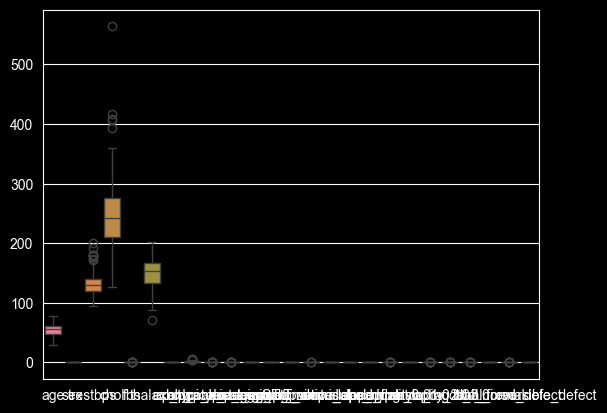

In [34]:
sns.boxplot(final_df)

In [35]:
from sklearn.preprocessing import MinMaxScaler

In [36]:
final_df.columns

Index(['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak',
       'cp_typical_angina', 'cp_atypical_angina', 'cp_non-anginal_pain',
       'cp_asymptomatic', 'restecg_normal', 'restecg_ST-T_wave_abnormality',
       'restecg_left_ventricular_hypertrophy', 'slope_upsloping', 'slope_flat',
       'slope_downsloping', 'ca_0.0', 'ca_1.0', 'ca_2.0', 'ca_3.0',
       'thal_normal', 'thal_fixed_defect', 'thal_reversible_defect'],
      dtype='str')

In [37]:
scaler = StandardScaler()
# scaler = MinMaxScaler()
final_df = scaler.fit_transform(final_df)

In [38]:
final_df = pd.DataFrame(final_df,columns = ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'cp_typical_angina', 'cp_atypical_angina','cp_non-anginal_pain','cp_asymptomatic', 'restecg_normal', 'restecg_ST-T_wave_abnormality','restecg_left_ventricular_hypertrophy', 'slope_upsloping','slope_flat','slope_downsloping', 'ca_0.0', 'ca_1.0', 'ca_2.0', 'ca_3.0','thal_normal', 'thal_fixed_defect', 'thal_reversible_defect'])
# final_df = pd.DataFrame(final_df,columns = ['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak','num', 'cp_typical_angina', 'cp_atypical_angina','cp_non-anginal_pain','cp_asymptomatic', 'restecg_normal', 'restecg_ST-T_wave_abnormality','restecg_left_ventricular_hypertrophy', 'slope_upsloping','slope_flat','slope_downsloping', 'ca_0.0', 'ca_1.0', 'ca_2.0', 'ca_3.0','thal_normal', 'thal_fixed_defect', 'thal_reversible_defect'])

In [39]:
final_df.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,cp_typical_angina,cp_atypical_angina,...,slope_upsloping,slope_flat,slope_downsloping,ca_0.0,ca_1.0,ca_2.0,ca_3.0,thal_normal,thal_fixed_defect,thal_reversible_defect
0,0.936181,0.691095,0.750380,-0.276443,2.430427,0.017494,-0.696419,1.068965,3.451528,-0.444500,...,-0.937948,-0.925338,3.625308,0.840771,-0.529313,-0.383038,-0.268705,-1.110443,3.937004,-0.794901
1,1.378929,0.691095,1.596266,0.744555,-0.411450,-1.816334,1.435916,0.381773,-0.289727,-0.444500,...,-0.937948,1.080686,-0.275839,-1.189384,-0.529313,-0.383038,3.721559,0.900542,-0.254000,-0.794901
2,1.378929,0.691095,-0.659431,-0.353500,-0.411450,-0.899420,1.435916,1.326662,-0.289727,-0.444500,...,-0.937948,1.080686,-0.275839,-1.189384,-0.529313,2.610707,-0.268705,-1.110443,-0.254000,1.258018
3,-1.941680,0.691095,-0.095506,0.051047,-0.411450,1.633010,-0.696419,2.099753,-0.289727,-0.444500,...,-0.937948,-0.925338,3.625308,0.840771,-0.529313,-0.383038,-0.268705,0.900542,-0.254000,-0.794901
4,-1.498933,-1.446980,-0.095506,-0.835103,-0.411450,0.978071,-0.696419,0.295874,-0.289727,2.249717,...,1.066157,-0.925338,-0.275839,0.840771,-0.529313,-0.383038,-0.268705,0.900542,-0.254000,-0.794901


<Axes: ylabel='Count'>

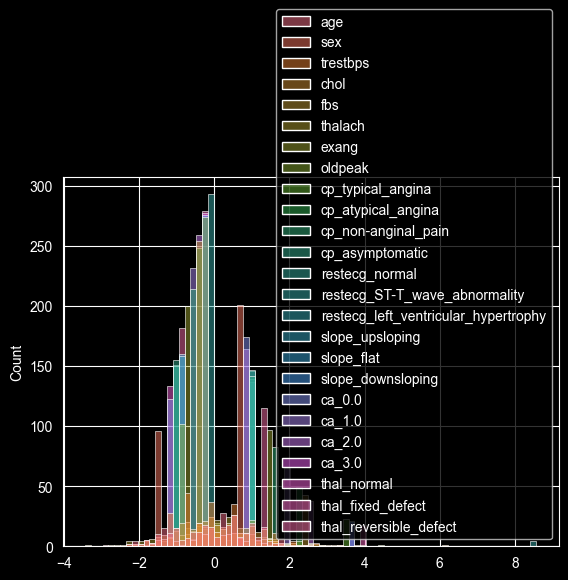

In [40]:
sns.histplot(final_df)

<Axes: >

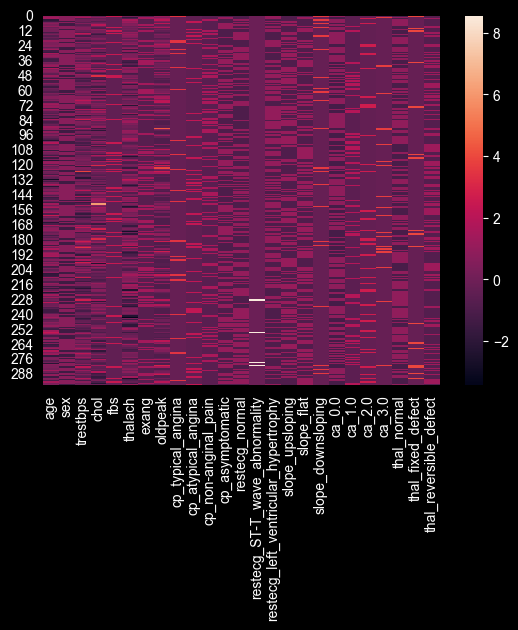

In [41]:
sns.heatmap(final_df)

<Axes: >

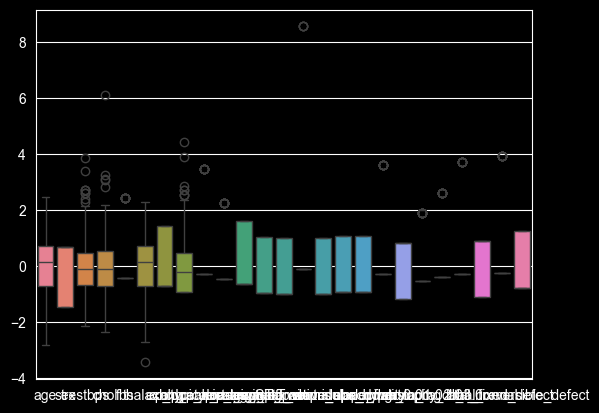

In [42]:
sns.boxplot(final_df)

In [43]:
final_df.describe().round(3)

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,cp_typical_angina,cp_atypical_angina,...,slope_upsloping,slope_flat,slope_downsloping,ca_0.0,ca_1.0,ca_2.0,ca_3.0,thal_normal,thal_fixed_defect,thal_reversible_defect
count,297.000,297.000,297.000,297.000,297.000,297.000,297.000,297.000,297.000,297.000,...,297.000,297.000,297.000,297.000,297.000,297.000,297.000,297.000,297.000,297.000
mean,-0.000,-0.000,0.000,-0.000,-0.000,0.000,-0.000,0.000,0.000,-0.000,...,0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000,0.000
std,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,...,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002,1.002
min,-2.827,-1.447,-2.126,-2.338,-0.411,-3.432,-0.696,-0.907,-0.290,-0.445,...,-0.938,-0.925,-0.276,-1.189,-0.529,-0.383,-0.269,-1.110,-0.254,-0.795
25%,-0.724,-1.447,-0.659,-0.700,-0.411,-0.725,-0.696,-0.907,-0.290,-0.445,...,-0.938,-0.925,-0.276,-1.189,-0.529,-0.383,-0.269,-1.110,-0.254,-0.795
50%,0.161,0.691,-0.096,-0.084,-0.411,0.148,-0.696,-0.220,-0.290,-0.445,...,-0.938,-0.925,-0.276,0.841,-0.529,-0.383,-0.269,0.901,-0.254,-0.795
75%,0.715,0.691,0.468,0.552,-0.411,0.716,1.436,0.468,-0.290,-0.445,...,1.066,1.081,-0.276,0.841,-0.529,-0.383,-0.269,0.901,-0.254,1.258
max,2.486,0.691,3.852,6.100,2.430,2.288,1.436,4.419,3.452,2.250,...,1.066,1.081,3.625,0.841,1.889,2.611,3.722,0.901,3.937,1.258


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
sns.set_theme(style="whitegrid")

Text(0.5, 1.0, 'Standardized Age vs. Max Heart Rate')

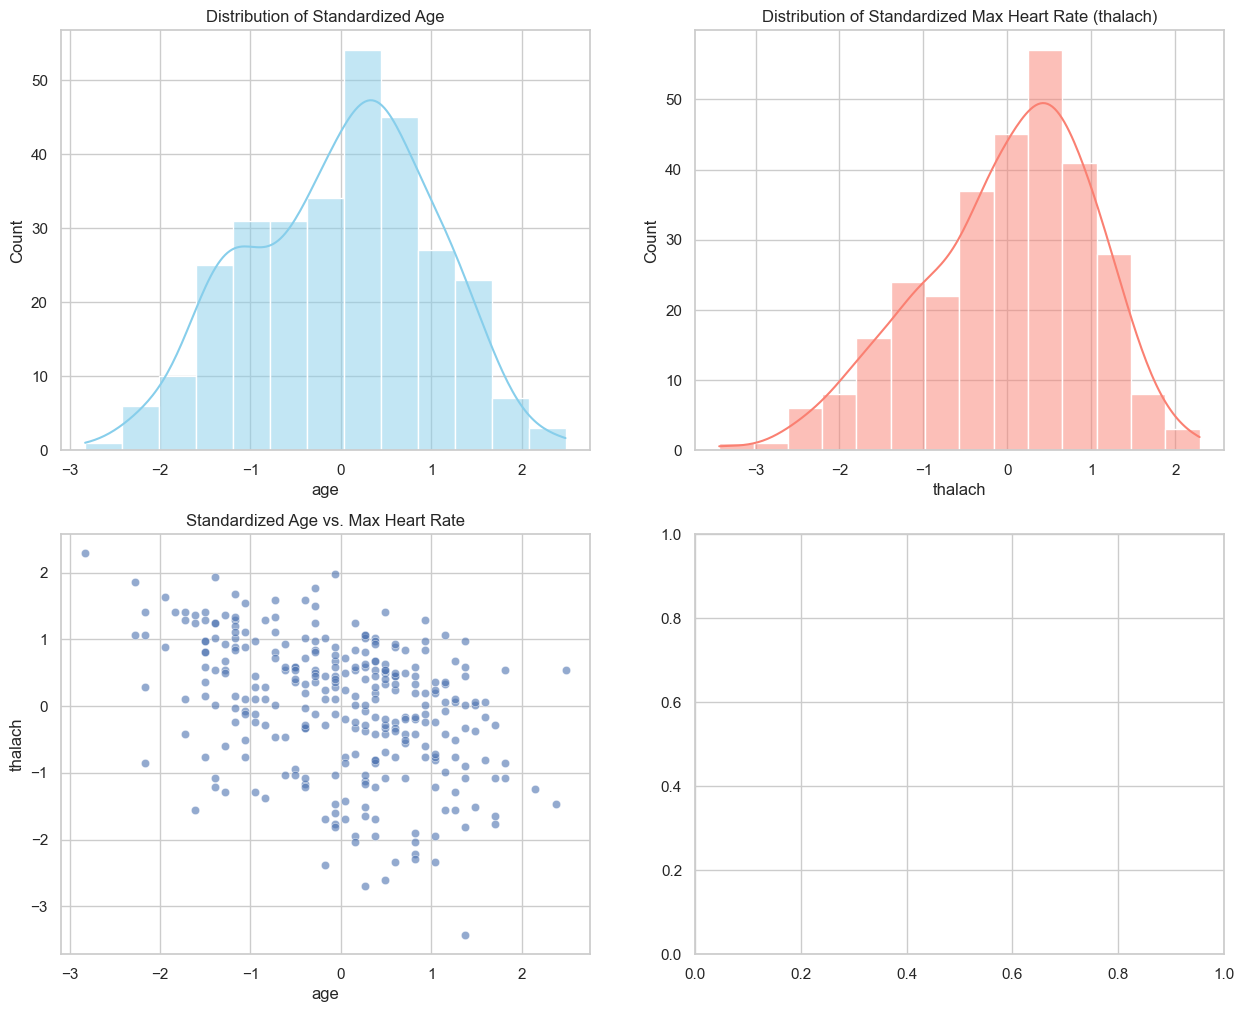

In [46]:
fig,axes = plt.subplots(2,2,figsize=(15,12))
sns.histplot(final_df['age'],kde=True,ax=axes[0,0],color="skyblue")
axes[0, 0].set_title('Distribution of Standardized Age')

sns.histplot(final_df['thalach'],kde=True,ax=axes[0,1],color="salmon")
axes[0, 1].set_title('Distribution of Standardized Max Heart Rate (thalach)')

sns.scatterplot(x='age',y='thalach',data=final_df,ax=axes[1,0],alpha=0.6)
axes[1, 0].set_title('Standardized Age vs. Max Heart Rate')

# sns.histplot(final_df['num'], kde=False, ax=axes[1, 1], bins=10)
# axes[1, 1].set_title('Distribution of Standardized Target (num)')
# plt.tight_layout()

Text(0.5, 1.0, 'Correlation Heatmap of Main Features')

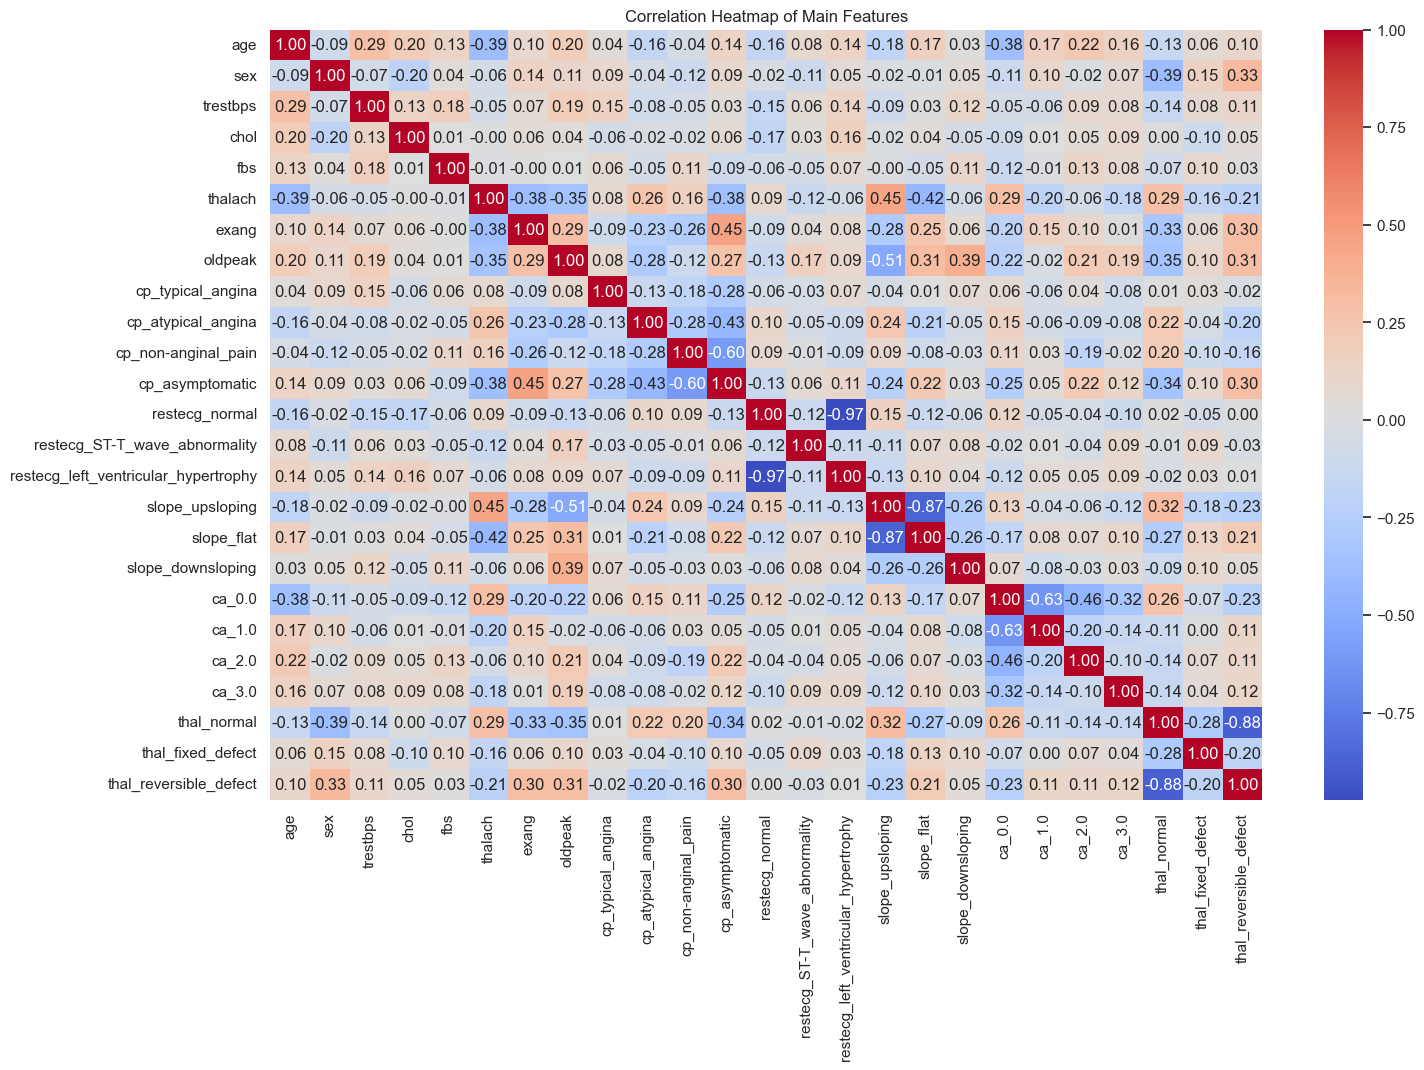

In [47]:
plt.figure(figsize=(16, 10))
main_cols = final_df.columns.tolist()
corr = final_df[main_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Main Features')

In [48]:
y = y.reset_index(drop=True)
y

0      0
1      1
2      1
3      0
4      0
      ..
292    1
293    1
294    1
295    1
296    1
Name: num, Length: 297, dtype: int64

In [49]:
final_df

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,cp_typical_angina,cp_atypical_angina,...,slope_upsloping,slope_flat,slope_downsloping,ca_0.0,ca_1.0,ca_2.0,ca_3.0,thal_normal,thal_fixed_defect,thal_reversible_defect
0,0.936181,0.691095,0.750380,-0.276443,2.430427,0.017494,-0.696419,1.068965,3.451528,-0.444500,...,-0.937948,-0.925338,3.625308,0.840771,-0.529313,-0.383038,-0.268705,-1.110443,3.937004,-0.794901
1,1.378929,0.691095,1.596266,0.744555,-0.411450,-1.816334,1.435916,0.381773,-0.289727,-0.444500,...,-0.937948,1.080686,-0.275839,-1.189384,-0.529313,-0.383038,3.721559,0.900542,-0.254000,-0.794901
2,1.378929,0.691095,-0.659431,-0.353500,-0.411450,-0.899420,1.435916,1.326662,-0.289727,-0.444500,...,-0.937948,1.080686,-0.275839,-1.189384,-0.529313,2.610707,-0.268705,-1.110443,-0.254000,1.258018
3,-1.941680,0.691095,-0.095506,0.051047,-0.411450,1.633010,-0.696419,2.099753,-0.289727,-0.444500,...,-0.937948,-0.925338,3.625308,0.840771,-0.529313,-0.383038,-0.268705,0.900542,-0.254000,-0.794901
4,-1.498933,-1.446980,-0.095506,-0.835103,-0.411450,0.978071,-0.696419,0.295874,-0.289727,2.249717,...,1.066157,-0.925338,-0.275839,0.840771,-0.529313,-0.383038,-0.268705,0.900542,-0.254000,-0.794901
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,0.272059,-1.446980,0.468418,-0.122330,-0.411450,-1.161395,1.435916,-0.734914,-0.289727,-0.444500,...,-0.937948,1.080686,-0.275839,0.840771,-0.529313,-0.383038,-0.268705,-1.110443,-0.254000,1.258018
293,-1.056185,0.691095,-1.223355,0.320744,-0.411450,-0.768432,-0.696419,0.124076,3.451528,-0.444500,...,-0.937948,1.080686,-0.275839,0.840771,-0.529313,-0.383038,-0.268705,-1.110443,-0.254000,1.258018
294,1.489615,0.691095,0.693988,-1.047008,2.430427,-0.375469,-0.696419,2.013854,-0.289727,-0.444500,...,-0.937948,1.080686,-0.275839,-1.189384,-0.529313,2.610707,-0.268705,-1.110443,-0.254000,1.258018
295,0.272059,0.691095,-0.095506,-2.241384,-0.411450,-1.510696,1.435916,0.124076,-0.289727,-0.444500,...,-0.937948,1.080686,-0.275839,-1.189384,1.889241,-0.383038,-0.268705,-1.110443,-0.254000,1.258018


In [50]:
final_df['num'] = y
final_df.to_csv("../data/heart_disease.csv",index = False)